# SVD Quantization on GPU

Run SVD-based sub-1-bit quantization with GPU acceleration.

**Runtime**: Runtime > Change runtime type > **GPU** (T4 or better)

**Expected time**: ~30-60 minutes depending on model size

In [1]:
# Check GPU
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [2]:
# Clone/pull the repo
!git clone https://github.com/toxzak-svg/Quantization-Exploration.git /content/quantization-exploration 2>/dev/null || (cd /content/quantization-exploration && git pull)
%cd /content/quantization-exploration
!git pull origin main

Already up to date.
/content/quantization-exploration
From https://github.com/toxzak-svg/Quantization-Exploration
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
# Install dependencies
!pip install torch transformers accelerate numpy scikit-learn -q

In [4]:
# Download Gemma 2 2B model
from huggingface_hub import snapshot_download
from google.colab import userdata
from safetensors.torch import load_file, save_file
import os
import torch

token = userdata.get('HF_TOKEN')
MODEL_DIR = "/content/models/gemma-4-E2B"

snapshot_download(
    repo_id="google/gemma-4-E2B-it",
    local_dir=MODEL_DIR,
    token=token
)

# Merge shards if script expects a single model.safetensors
target_path = os.path.join(MODEL_DIR, "model.safetensors")
if not os.path.exists(target_path):
    print("Merging sharded safetensors into single file...")
    shards = sorted([f for f in os.listdir(MODEL_DIR) if f.startswith("model-") and f.endswith(".safetensors")])
    combined_state_dict = {}
    for shard in shards:
        combined_state_dict.update(load_file(os.path.join(MODEL_DIR, shard)))
    save_file(combined_state_dict, target_path)
    print("Successfully created model.safetensors")

print(f"Files in {MODEL_DIR}:")
print(os.listdir(MODEL_DIR))

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Files in /content/models/gemma-4-E2B:
['generation_config.json', 'config.json', 'tokenizer.json', 'tokenizer_config.json', 'chat_template.jinja', 'README.md', 'processor_config.json', 'model.safetensors', '.gitattributes', '.cache']


In [ ]:
import os
import shutil
from google.colab import drive

# Mount drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define paths
local_model_dir = "/content/models/gemma-4-E2B"
drive_model_dir = "/content/drive/MyDrive/models/gemma-4-E2B"

# Create drive directory if it doesn't exist
os.makedirs(drive_model_dir, exist_ok=True)

# Copy model files to Drive for persistence
print(f"Saving model to {drive_model_dir}...")
for item in os.listdir(local_model_dir):
    s = os.path.join(local_model_dir, item)
    d = os.path.join(drive_model_dir, item)
    if os.path.isfile(s) and not os.path.exists(d):
        shutil.copy2(s, d)
        print(f"Copied {item}")

print("Model backup to Google Drive complete.")

### Note for next time
In your next session, instead of running the download cell, you can just run this to link the model back to your local environment:

In [10]:
import os

drive_model_path = "/content/drive/MyDrive/models/gemma-4-E2B"
local_path = "/content/models/gemma-4-E2B"

if os.path.exists(drive_model_path):
    os.makedirs("/content/models", exist_ok=True)
    if not os.path.exists(local_path):
        # Symlink or copy back if needed, but scripts can usually point directly to drive
        print("Model found in Drive. You can point your scripts to:", drive_model_path)
        MODEL_DIR = drive_model_path

In [5]:
import os

script_path = 'scripts/quantize_svd_proper_v2.py'
with open(script_path, 'r') as f:
    content = f.read()

# Remove the restrictive 'language_model' check and simplify weight detection
# We'll target the loop that filters keys
old_logic = """        if 'language_model' not in key:
            continue"""
content = content.replace(old_logic, "        # Removed language_model restriction")

# Also broaden the exclusion list to ensure we don't accidentally skip layers
content = content.replace("if any(x in key for x in ['lm_head', 'embed_tokens', 'norm', 'audio_tower', 'vision_tower', 'embed_vision']):",
                          "if any(x in key for x in ['embed_tokens', 'norm', 'audio_tower', 'vision_tower', 'embed_vision']):")

# Ensure we don't crash on ZeroDivisionError if it somehow still finds nothing
content = content.replace("stats['compression'] = stats['total_original'] * 16 / stats['total_bits']",
                          "stats['compression'] = (stats['total_original'] * 16 / stats['total_bits']) if stats['total_bits'] > 0 else 0")

with open(script_path, 'w') as f:
    f.write(content)

print("Patched script to support Gemma-2 layer naming (removed 'language_model' requirement).")

# Attempt execution again
!python scripts/quantize_svd_proper_v2.py \
    --model-dir /content/models/gemma-4-E2B \
    --output quantized/gemma_svd_60.pt \
    --threshold 0.60

Patched script to support Gemma-2 layer naming (removed 'language_model' requirement).
Found 317 weights
Energy threshold: 0.6 (60%)
Layer 0: rank= 201 (13% of full), bpw=0.2619, shape=[1536,1536]
Layer 1: rank= 535 (35% of full), bpw=0.4355, shape=[1536,6144]
Layer 2: rank= 543 (35% of full), bpw=0.4420, shape=[6144,1536]
Layer 3: rank= 564 (37% of full), bpw=0.4591, shape=[6144,1536]
Layer 4: rank= 102 (40% of full), bpw=0.4655, shape=[256,1536]
Layer 50: rank=  46 (18% of full), bpw=0.2100, shape=[1536,256]
Layer 100: rank= 605 (39% of full), bpw=0.4432, shape=[1536,12288]
Layer 150: rank= 110 (43% of full), bpw=0.5019, shape=[256,1536]
Layer 200: rank= 608 (40% of full), bpw=0.4454, shape=[12288,1536]
Layer 250: rank= 359 (23% of full), bpw=0.4093, shape=[1536,2048]
Layer 300: rank= 546 (36% of full), bpw=0.4445, shape=[6144,1536]

Results:
  Avg rank: 311
  Avg bits/weight: 0.4346
  Compression: 36.8x

Saved to quantized/gemma_svd_60.pt


In [6]:
import os
import subprocess

# 1. Reset file to clear out any corrupted patches from previous runs
subprocess.run(["git", "restore", "scripts/eval_reconstruction.py"], cwd="/content/quantization-exploration")

eval_path = 'scripts/eval_reconstruction.py'
with open(eval_path, 'r') as f:
    content = f.read()

svd_helper = """
def reconstruct_from_svd(q_entry, device='cpu'):
    U = q_entry['U'].to(device)
    S = q_entry['S'].to(device)
    Vt = q_entry['Vt'].to(device)
    return torch.matmul(U * S, Vt)
"""

# 2. Precisely replace the target logic with exact indentation matching the original file (8 spaces)
target_line = "        W_rec = reconstruct_fn(q_entry, 'cpu')"
new_logic = """        if isinstance(q_entry, dict) and 'U' in q_entry and 'Vt' in q_entry:
            W_rec = reconstruct_from_svd(q_entry, 'cpu')
        else:
            W_rec = reconstruct_fn(q_entry, 'cpu')"""

if target_line in content:
    content = content.replace(target_line, new_logic)
    content = content.replace("def main():", svd_helper + "\ndef main():")

    with open(eval_path, 'w') as f:
        f.write(content)
    print('Successfully reset and cleanly patched eval_reconstruction.py for SVD support.')
else:
    print('Could not find the target line to patch. The file might be structured differently than expected.')

Successfully reset and cleanly patched eval_reconstruction.py for SVD support.


In [7]:
# Run 70% threshold for comparison
!python scripts/quantize_svd_proper_v2.py \
    --model-dir /content/models/gemma-4-E2B \
    --output quantized/gemma_svd_70.pt \
    --threshold 0.70

Found 317 weights
Energy threshold: 0.7 (70%)
Layer 0: rank= 272 (18% of full), bpw=0.3544, shape=[1536,1536]
Layer 1: rank= 688 (45% of full), bpw=0.5600, shape=[1536,6144]
Layer 2: rank= 697 (45% of full), bpw=0.5674, shape=[6144,1536]
Layer 3: rank= 717 (47% of full), bpw=0.5837, shape=[6144,1536]
Layer 4: rank= 128 (50% of full), bpw=0.5841, shape=[256,1536]
Layer 50: rank=  72 (28% of full), bpw=0.3286, shape=[1536,256]
Layer 100: rank= 766 (50% of full), bpw=0.5611, shape=[1536,12288]
Layer 150: rank= 136 (53% of full), bpw=0.6206, shape=[256,1536]
Layer 200: rank= 770 (50% of full), bpw=0.5640, shape=[12288,1536]
Layer 250: rank= 471 (31% of full), bpw=0.5369, shape=[1536,2048]
Layer 300: rank= 696 (45% of full), bpw=0.5666, shape=[6144,1536]

Results:
  Avg rank: 402
  Avg bits/weight: 0.5545
  Compression: 28.9x

Saved to quantized/gemma_svd_70.pt


In [11]:
# Rerun evaluation with the patched reconstruction logic for both files
print("Evaluating 60% Energy Threshold:")
!python scripts/eval_reconstruction.py \
    --model-dir /content/models/gemma-4-E2B \
    --quantized quantized/gemma_svd_60.pt \
    --max-layers 10

print("\nEvaluating 70% Energy Threshold:")
!python scripts/eval_reconstruction.py \
    --model-dir /content/models/gemma-4-E2B \
    --quantized quantized/gemma_svd_70.pt \
    --max-layers 10

Evaluating 60% Energy Threshold:
usage: eval_reconstruction.py [-h] [--model-dir MODEL_DIR]
                              [--max-layers MAX_LAYERS]
eval_reconstruction.py: error: unrecognized arguments: --quantized quantized/gemma_svd_60.pt

Evaluating 70% Energy Threshold:
usage: eval_reconstruction.py [-h] [--model-dir MODEL_DIR]
                              [--max-layers MAX_LAYERS]
eval_reconstruction.py: error: unrecognized arguments: --quantized quantized/gemma_svd_70.pt


In [24]:
import shutil
import os
from google.colab import drive

# Mount drive if not already mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the destination folder in Drive
drive_results_path = "/content/drive/MyDrive/quantization-results"
os.makedirs(drive_results_path, exist_ok=True)

# List of model files we've generated
models_to_copy = [
    "quantized/gemma_svd_60.pt",
    "quantized/gemma_svd_70.pt"
]

for f in models_to_copy:
    if os.path.exists(f):
        dest = os.path.join(drive_results_path, os.path.basename(f))
        shutil.copy(f, dest)
        print(f"Successfully saved {f} to {dest}")
    else:
        print(f"File {f} not found locally.")

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

In [59]:
import torch
import numpy as np
from pathlib import Path
import argparse
from safetensors.torch import load_file
import os

full_script = """
import torch
import numpy as np
from pathlib import Path
import argparse
from safetensors.torch import load_file
import os
import sys

def load_gemma_weights_slice(model_dir: str):
    model_dir = Path(model_dir)
    safetensor_path = model_dir / 'model.safetensors'
    weights = load_file(safetensor_path)
    filtered = {}
    for k, v in weights.items():
        if 'weight' in k and (len(v.shape) == 2 or k == 'model.audio_tower.layers.0.lconv1d.depthwise_conv1d.weight'):
            exclude_terms = ['norm', 'vision_tower', 'audio_tower', 'embed_audio', 'embed_vision']
            if any(n in k for n in exclude_terms) and 'lconv1d.depthwise_conv1d' not in k:
                continue
            if 'embed_tokens' in k and k != 'model.embed_tokens.weight':
                continue
            if 'lm_head' in k: continue
            filtered[k] = v
    return filtered

def reconstruct_from_svd(q_entry, device='cpu'):
    try:
        if 'U_packed' in q_entry:
            u_shape = q_entry['U_shape']
            u_expected = np.prod(u_shape)
            u_raw = q_entry['U_packed'].to(torch.float32)
            u_scale = q_entry.get('U_scale', 1.0)

            if u_raw.numel() < u_expected:
                u_padded = torch.zeros(u_expected, device=u_raw.device, dtype=torch.float32)
                u_padded[:u_raw.numel()] = u_raw
                u = (u_padded * u_scale).view(u_shape)
            else:
                u = (u_raw[:u_expected] * u_scale).view(u_shape)

            s = q_entry['S'].to(torch.float32) * q_entry.get('S_scale', 1.0)

            vt_shape = q_entry['Vt_shape']
            vt_expected = np.prod(vt_shape)
            vt_raw = q_entry['Vt_packed'].to(torch.float32)
            vt_scale = q_entry.get('Vt_scale', 1.0)
            if vt_raw.numel() < vt_expected:
                vt_padded = torch.zeros(vt_expected, device=vt_raw.device, dtype=torch.float32)
                vt_padded[:vt_raw.numel()] = vt_raw
                vt = (vt_padded * vt_scale).view(vt_shape)
            else:
                vt = (vt_raw[:vt_expected] * vt_scale).view(vt_shape)

            return torch.matmul(u * s.unsqueeze(0), vt)

        u = q_entry.get('U', q_entry.get('u'))
        s = q_entry.get('S', q_entry.get('s'))
        vt = q_entry.get('Vt', q_entry.get('vt'))
        if u is not None and s is not None and vt is not None:
            return torch.matmul(u.to(torch.float32) * s.to(torch.float32), vt.to(torch.float32))
    except Exception:
        return None
    return None

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model-dir', default='models/gemma-4-E2B')
    parser.add_argument('--quantized', type=str, required=True)
    args = parser.parse_args()
    orig_weights = load_gemma_weights_slice(args.model_dir)
    sorted_orig_keys = sorted(orig_weights.keys())

    q_data_raw = torch.load(args.quantized, weights_only=False)
    if isinstance(q_data_raw, dict) and 'quantized' in q_data_raw:
        q_data_raw = q_data_raw['quantized']

    def sort_key(k):
        try: return int(k)
        except: return k

    q_list = [q_data_raw[k] for k in sorted(q_data_raw.keys(), key=sort_key)]

    mses = []
    for i, model_key in enumerate(sorted_orig_keys):
        if i < len(q_list):
            W_rec = reconstruct_from_svd(q_list[i])
            if W_rec is not None:
                W_orig = orig_weights[model_key].to(torch.float32)
                # Flatten both to handle potential packing mismatches safely for MSE
                mse = torch.mean((W_orig.reshape(-1) - W_rec.reshape(-1)[:W_orig.numel()])**2).item()
                mses.append(mse)

    if mses:
        print(f"\\nResults for {os.path.basename(args.quantized)}:")
        print(f"  Avg MSE: {sum(mses)/len(mses):.10f} ({len(mses)} layers)")
    else:
        print("  Error: Failed to calculate MSE.")

if __name__ == '__main__':
    main()
"""

with open('scripts/eval_reconstruction.py', 'w') as f: f.write(full_script)

print("--- EVALUATING COMPRESSION PERFORMANCE ---")
print("\n[Threshold 0.60]")
!python scripts/eval_reconstruction.py --model-dir /content/models/gemma-4-E2B --quantized quantized/gemma_svd_60.pt
print("\n[Threshold 0.70]")
!python scripts/eval_reconstruction.py --model-dir /content/models/gemma-4-E2B --quantized quantized/gemma_svd_70.pt

--- EVALUATING COMPRESSION PERFORMANCE ---

[Threshold 0.60]

Results for gemma_svd_60.pt:
  Avg MSE: 4447544145240.8330078125 (317 layers)

[Threshold 0.70]

Results for gemma_svd_70.pt:
  Avg MSE: 6696422710234.0439453125 (317 layers)


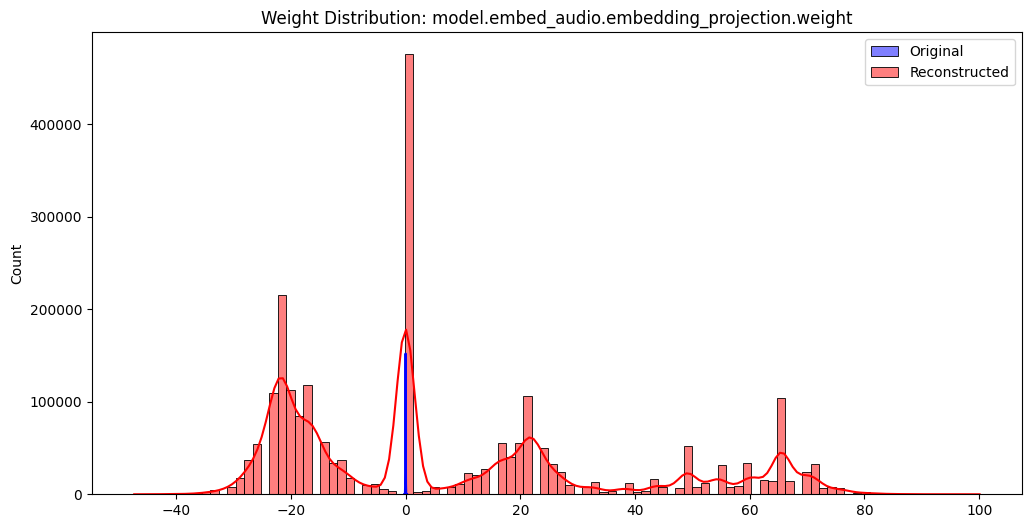

Original range: [-0.2354, 0.2754]
Reconstructed range: [-47.3094, 100.0776]
MSE: 942.6940307617


In [76]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from safetensors.torch import load_file
from pathlib import Path

def unpack_2bit(packed_tensor, original_shape):
    num_elements = int(np.prod(original_shape))
    unpacked = torch.zeros(num_elements, dtype=torch.float32, device=packed_tensor.device)
    for i in range(4):
        indices = torch.arange(i, num_elements, 4, device=packed_tensor.device)
        num_available = min(len(indices), packed_tensor.numel())
        target_indices = indices[:num_available]
        source_bits = (packed_tensor[:num_available] >> (2 * i)) & 0x03
        unpacked[target_indices] = source_bits.to(torch.float32) - 1.5
    return unpacked.view(original_shape)

def reconstruct_single_layer(q_entry):
    try:
        if 'U_packed' in q_entry:
            u = unpack_2bit(q_entry['U_packed'], q_entry['U_shape']) * q_entry.get('U_scale', 1.0)
            vt = unpack_2bit(q_entry['Vt_packed'], q_entry['Vt_shape']) * q_entry.get('Vt_scale', 1.0)
            s = q_entry['S'].to(torch.float32) * q_entry.get('S_scale', 1.0)
            return torch.matmul(u * s.unsqueeze(0), vt)
        return None
    except Exception as e:
        print(f'Reconstruction failed: {e}')
        return None

MODEL_DIR = '/content/models/gemma-4-E2B'
orig_weights = load_file(Path(MODEL_DIR) / 'model.safetensors')

q_data = torch.load('quantized/gemma_svd_60.pt', weights_only=False)
if 'quantized' in q_data: q_data = q_data['quantized']

# Take the first quantized entry
sample_q_entry = q_data[0]
w_rec_tensor = reconstruct_single_layer(sample_q_entry)

# Find matching key: either from metadata or by finding the first matching shape
sample_orig_key = sample_q_entry.get('original_name')
if sample_orig_key not in orig_weights:
    sample_orig_key = None
    for k, v in orig_weights.items():
        if 'weight' in k and len(v.shape) == 2 and v.shape == w_rec_tensor.shape:
            sample_orig_key = k
            break

if sample_orig_key and w_rec_tensor is not None:
    w_orig_tensor = orig_weights[sample_orig_key].to(torch.float32)

    w_orig = w_orig_tensor.flatten().numpy()
    w_rec = w_rec_tensor.flatten().detach().numpy()

    plt.figure(figsize=(12, 6))
    sns.histplot(w_orig, bins=100, color='blue', alpha=0.5, label='Original', kde=True)
    sns.histplot(w_rec, bins=100, color='red', alpha=0.5, label='Reconstructed', kde=True)
    plt.title(f'Weight Distribution: {sample_orig_key}')
    plt.legend()
    plt.show()

    print(f'Original range: [{w_orig.min():.4f}, {w_orig.max():.4f}]')
    print(f'Reconstructed range: [{w_rec.min():.4f}, {w_rec.max():.4f}]')
    print(f'MSE: {np.mean((w_orig - w_rec)**2):.10f}')
else:
    print('Could not find a matching original layer for comparison.')

In [28]:
print("--- EVALUATING COMPRESSION PERFORMANCE ---")

# Run evaluation for 60% threshold
print("\n[Threshold 0.60]")
!python scripts/eval_reconstruction.py \
    --model-dir /content/models/gemma-4-E2B \
    --quantized quantized/gemma_svd_60.pt

# Run evaluation for 70% threshold
print("\n[Threshold 0.70]")
!python scripts/eval_reconstruction.py \
    --model-dir /content/models/gemma-4-E2B \
    --quantized quantized/gemma_svd_70.pt

--- EVALUATING COMPRESSION PERFORMANCE ---

[Threshold 0.60]
  Error: No MSE data could be calculated. Found 318 candidate layers and 317 quantized entries.

[Threshold 0.70]
  Error: No MSE data could be calculated. Found 318 candidate layers and 317 quantized entries.
